In [2]:
import os
import re
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from PIL import Image
from IPython.display import display, Markdown

FIG_DIR = "../visualizations"
os.makedirs(FIG_DIR, exist_ok=True)

print("OK: imports + folders ready")

OK: imports + folders ready


In [3]:
CSV_PATH = "../metadata.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded metadata from {CSV_PATH} with {len(df):,} QA rows")
else:
    ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")
    df = ds['raw'].select_columns(['source','question','answer','img_id']).to_pandas()
    os.makedirs(os.path.dirname(CSV_PATH), exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    print(f"Saved metadata to {CSV_PATH} with {len(df):,} QA rows")

# Basic sanity
display(df.head())

Loaded metadata from ../metadata.csv with 58,849 QA rows


,source,question,answer,img_id
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq


Total QA pairs: 58,849
Unique images:  6,500

QA per image (describe):


count    6500.000000
mean        9.053692
std         7.017818
min         1.000000
25%         1.000000
50%         9.000000
75%        17.000000
max        18.000000
Name: count, dtype: float64

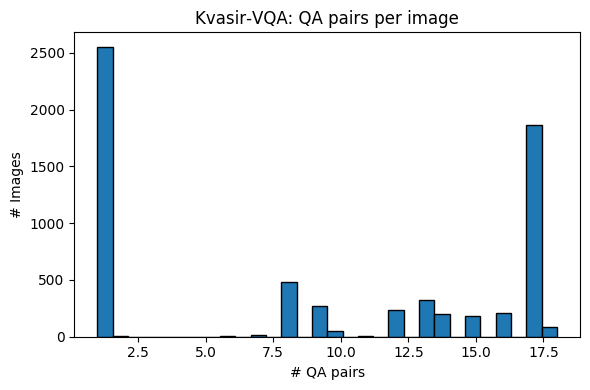

In [4]:
n_qa = len(df)
n_imgs = df['img_id'].nunique()
qa_per_img = df['img_id'].value_counts()

print(f"Total QA pairs: {n_qa:,}")
print(f"Unique images:  {n_imgs:,}")
print("\nQA per image (describe):")
display(qa_per_img.describe())

# histogram: QA per image
plt.figure(figsize=(6,4))
plt.hist(qa_per_img.values, bins=30, edgecolor="black")
plt.title("Kvasir‑VQA: QA pairs per image")
plt.xlabel("# QA pairs")
plt.ylabel("# Images")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qa_per_image_hist.png", dpi=200)
plt.show()

QA pairs by source:


source
Ulcerative Colitis    16890
Esophagitis           16723
Polyps                13539
Instrument             9197
Normal                 2500
Name: count, dtype: int64

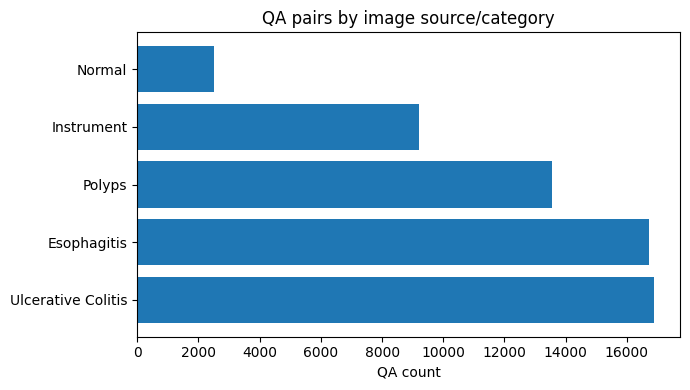

Unique images by source:


source
Normal                2500
Esophagitis           1000
Instrument            1000
Polyps                1000
Ulcerative Colitis    1000
Name: img_id, dtype: int64

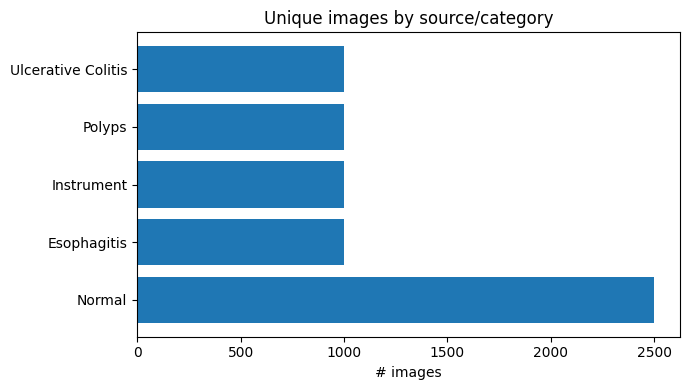

In [5]:
by_source_qa = df['source'].value_counts().sort_values(ascending=False)
print("QA pairs by source:")
display(by_source_qa)

plt.figure(figsize=(7,4))
plt.barh(by_source_qa.index.astype(str), by_source_qa.values)
plt.title("QA pairs by image source/category")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qa_by_source.png", dpi=200)
plt.show()

img_source = df.groupby('source')['img_id'].nunique().sort_values(ascending=False)
print("Unique images by source:")
display(img_source)

plt.figure(figsize=(7,4))
plt.barh(img_source.index.astype(str), img_source.values)
plt.title("Unique images by source/category")
plt.xlabel("# images")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/images_by_source.png", dpi=200)
plt.show()

question_type
Yes/No      26515
Entity      10528
Counting    10118
Location     8424
Color        3213
Other          51
Name: count, dtype: int64

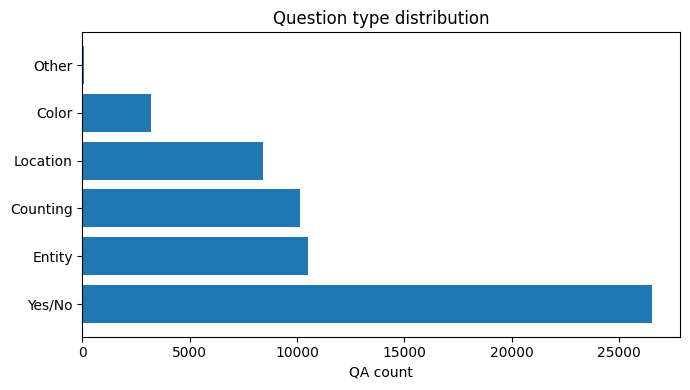

In [6]:
_qtype_regex = [
    ("Counting", re.compile(r"\bhow many\b", re.I)),
    ("Yes/No",  re.compile(r"^(is|are|does|do|can|has|have)\b", re.I)),
    ("Location",re.compile(r"\b(where|which region|which part)\b", re.I)),
    ("Color",   re.compile(r"\bcolor\b", re.I)),
    ("Entity",  re.compile(r"^(what|which)\b", re.I)),
]

def classify_qtype(q: str) -> str:
    if not isinstance(q, str): 
        return "Other"
    for label, rgx in _qtype_regex:
        if rgx.search(q):
            return label
    return "Other"

df['question_type'] = df['question'].astype(str).apply(classify_qtype)
display(df['question_type'].value_counts())

counts = df['question_type'].value_counts()
plt.figure(figsize=(7,4))
plt.barh(counts.index.astype(str), counts.values)
plt.title("Question type distribution")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/question_type_distribution.png", dpi=200)
plt.show()

In [7]:
def normalize_q(q):
    q = str(q).strip().lower()
    q = re.sub(r"\s+", " ", q)
    q = re.sub(r"[?!.]+$", "", q)
    return q

df['question_norm'] = df['question'].apply(normalize_q)
template_counts = df['question_norm'].value_counts()
print("Top 25 question templates:")
display(template_counts.head(25))

template_counts.head(50).to_csv(f"{FIG_DIR}/top_question_templates.csv")

Top 25 question templates:


question_norm
have all polyps been removed                                                   3945
is this finding easy to detect                                                 3941
is there text                                                                  3941
is there a green/black box artefact                                            3940
what type of procedure is the image taken from                                 3939
how many instrumnets are in the image                                          3555
how many findings are present                                                  3429
what type of polyp is present                                                  3331
what is the size of the polyp                                                  3258
where in the image is the instrument                                           3154
are there any instruments in the image? check all that are present             3148
how many polyps are in the image                              

answer_type
Yes/No     15243
None/NA    13544
Token      12151
Numeric    10118
List        7793
Name: count, dtype: int64

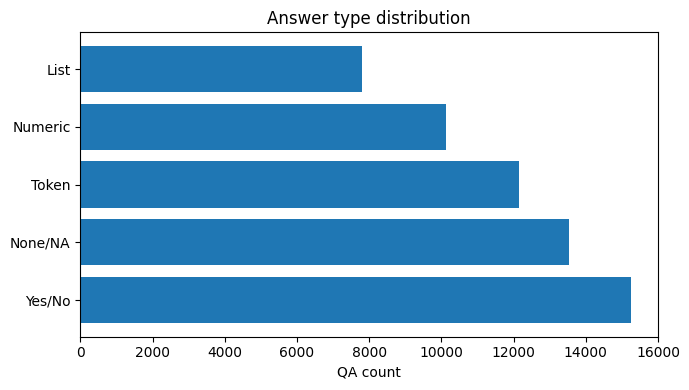

Top 20 specific answers (non‑trivial):


answer
0                                                                                                                  4538
1                                                                                                                  4380
colonoscopy                                                                                                        2944
center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right    1794
pink; red; white                                                                                                   1271
polyp                                                                                                              1137
2                                                                                                                  1116
gastroscopy                                                                                                         993
ulcerative colitis               

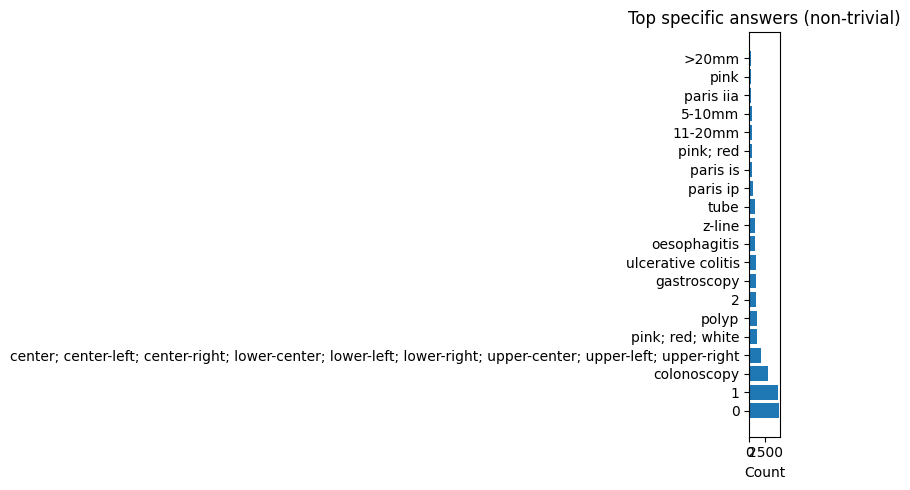

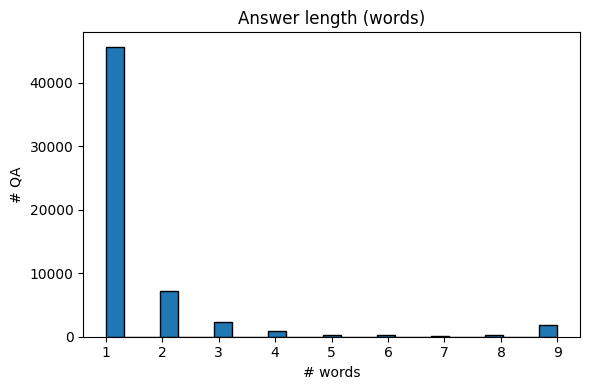

In [8]:
def answer_type(a: str) -> str:
    s = str(a).strip().lower()
    if s in {"yes", "no"}:
        return "Yes/No"
    if s in {"none", "no finding", "not relevant", "not_applicable"}:
        return "None/NA"
    if re.fullmatch(r"\d+", s):
        return "Numeric"
    if ";" in s or "," in s:
        return "List"
    return "Token"

df['answer_type'] = df['answer'].apply(answer_type)
display(df['answer_type'].value_counts())

counts = df['answer_type'].value_counts()
plt.figure(figsize=(7,4))
plt.barh(counts.index.astype(str), counts.values)
plt.title("Answer type distribution")
plt.xlabel("QA count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/answer_type_distribution.png", dpi=200)
plt.show()

mask_specific = ~df['answer'].str.strip().str.lower().isin(
    ["yes","no","none","no finding","not relevant","not_applicable"]
)
top_answers = df.loc[mask_specific, 'answer'].value_counts().head(20)
print("Top 20 specific answers (non‑trivial):")
display(top_answers)

plt.figure(figsize=(8,5))
plt.barh(top_answers.index.astype(str), top_answers.values)
plt.title("Top specific answers (non‑trivial)")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_specific_answers.png", dpi=200)
plt.show()

df['answer_len_words'] = df['answer'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
plt.hist(df['answer_len_words'], bins=25, edgecolor="black")
plt.title("Answer length (words)")
plt.xlabel("# words")
plt.ylabel("# QA")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/answer_len_hist.png", dpi=200)
plt.show()

question_type,Color,Counting,Entity,Location,Other,Yes/No
source,,,,,,
Esophagitis,1077,2967,2967,2964,11,6737
Instrument,164,1595,1265,1129,26,5018
Normal,0,0,0,0,0,2500
Polyps,978,2576,3316,1354,8,5307
Ulcerative Colitis,994,2980,2980,2977,6,6953


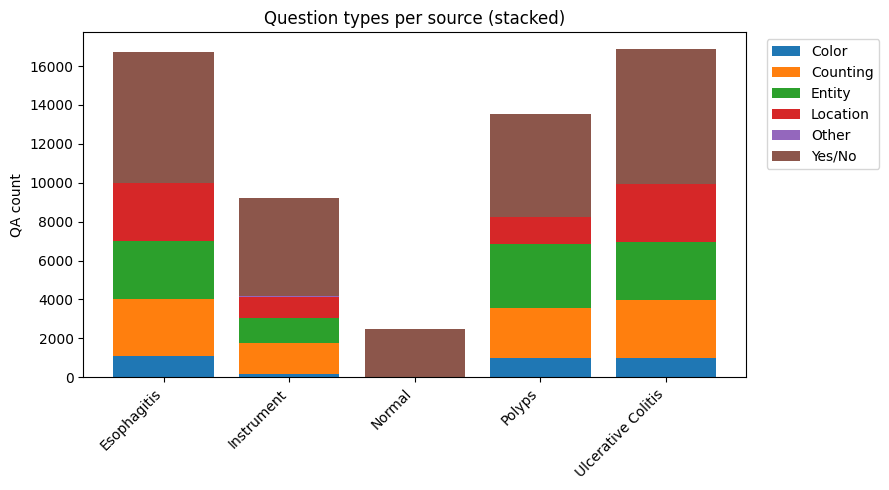

In [9]:
ct = pd.crosstab(df['source'], df['question_type']).sort_index()
display(ct)

ct.to_csv(f"{FIG_DIR}/crosstab_source_qtype.csv")

plt.figure(figsize=(9,5))
bottom = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values
    plt.bar(ct.index.astype(str), vals, bottom=bottom, label=col)
    bottom += vals
plt.title("Question types per source (stacked)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("QA count")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/qtype_per_source_stacked.png", dpi=200)
plt.show()

In [10]:
def show_image_and_qas(img_id, qas=5):
    
    sample = None
    try:
        ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")
        # picking first row for this img_id to get image
        row_idx = df.index[df['img_id']==img_id][0]
        sample = ds['raw'][row_idx]
        img = sample['image']  # PIL
    except Exception:
        # adding a fallback: local image path
        img_path = f"./images/{img_id}.jpg"
        img = Image.open(img_path).convert("RGB")
    
    display(img)
    subset = df[df['img_id']==img_id].head(qas)[['question','answer']]
    display(subset)

# Picking one image per key source if it's available
for src in df['source'].dropna().unique()[:5]:
    img_id = df.loc[df['source']==src, 'img_id'].iloc[0]
    display(Markdown(f"### Source: **{src}** — img_id: `{img_id}`"))
    show_image_and_qas(img_id, qas=6)

### Source: **Ulcerative Colitis** — img_id: `cla820gl0s3nv071u4fgd7xgq`

FileNotFoundError: [Errno 2] No such file or directory: './images/cla820gl0s3nv071u4fgd7xgq.jpg'